
# VLA-style layer-locked readout vs. closed-form EI

Trains `models/layer_locked_readout.py`'s `LayerLockedReadout` (the VLA-action-expert-style,
per-PFN-layer sequential cross-attention readout — see that module's docstring for the full
rationale vs. `docs/ROADMAP.md` §3.2's flat-concat design) to predict EI, using ONLY the frozen
PFN's train-token hidden states — never the frozen model's own query-conditioned output. Ground
truth is the closed-form EI from the SAME frozen model's own bar distribution
(`model.bar_dist.ei`), on the SAME BNN instance and the SAME train/query points the readout sees.

**Incumbent marker: one per layer, not once at the start.** The marker is added directly to each
layer's already-computed frozen hidden state (`H^l[incumbent_idx] += marker[l]`) — it never
touches the frozen PFN's own forward pass, which already finished computing `H^0, ..., H^{L-1}`
independently before the readout ever runs. Because of that, marking only feeds back through the
readout's OWN residual stream (`h`, layer to layer); it does NOT propagate into the frozen model's
per-layer outputs the way an input-level marker (e.g. BERT's segment embedding) would. Marking once
at the very first layer would leave every later cross-attention round reading an un-marked `H^l`
(the incumbent's token at layer `l>0` looks like any other train token), with no reliable way for
the readout to relocate it. So each layer needs its own marker for the mechanism to work at every
round — that's what's implemented, `n_layers` separate learned vectors, not one shared or applied
only once.

Ground-truth EI computed via `model.bar_dist.ei(logits, best_f=y_incumbent.unsqueeze(-1))` — the
`.unsqueeze(-1)` matters: `BarDistribution.ei()` now asserts `best_f.dim() == logits.dim() - 1`
after a bug where omitting it silently mixed up different environments' incumbents (see
`models/bar_distribution.py` and its regression tests). Target is `log10(EI / best_f)`, not
`log10(EI)` directly — EI is bounded to `[0, best_f] ⊆ [0,1]` here (the checkpoint's bar
distribution has fixed `[0,1]` borders, not an unbounded tail), so normalizing by `best_f` removes
cross-environment scale as a confound and makes `log10(·) ≤ 0` an exact bound, not incidental.

**A note on the scatter plot's spread.** Unlike a realized (Monte Carlo) reward target, `ei_true`
is a DETERMINISTIC, closed-form function of `(x_train, y_train, x_query)` — there is no intrinsic
label noise here. So any spread around `y = x` in the log-log scatter is entirely readout
prediction error, not an irreducible noise floor; it should, in principle, keep shrinking with more
training/capacity rather than plateau at some inherent limit. Log-log axes also visually exaggerate
spread for a heavy-tailed quantity spanning many decades — a fixed *relative* error looks wider at
the low end than the high end purely from the log compression — so this notebook reports the
log-space MAE/RMSE and per-instance rank statistics alongside the plot, not just the picture.

**Run config:** long budget, GPU (`ulysses`) — see `N_STEPS` below; auto-detects `cuda`.


In [1]:

import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import spearmanr

from anytimeacquisition.models.bar_distribution import BarDistribution, uniform_bin_borders
from anytimeacquisition.models.layer_locked_readout import LayerLockedReadout
from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model, _, ckpt = load_pfn_checkpoint("../models/pfn_variable_xdim_smoke.pt", device=device)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)
print("frozen PFN config:", ckpt["config"])

X_DIM = ckpt["config"]["max_x_dim"]
D_MODEL_PFN = ckpt["config"]["d_model"]
N_LAYERS = ckpt["config"]["n_layers"]


/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
frozen PFN config: {'max_x_dim': 6, 'd_model': 64, 'n_heads': 4, 'n_layers': 4, 'd_ff': 128, 'n_bins': 64}


In [2]:

D_EXPERT, N_HEADS_EXPERT, D_FF_EXPERT = 32, 4, 64
N_BINS, Z_LO, Z_HI, EPS = 64, -6.0, 0.0, 1e-8

readout = LayerLockedReadout(D_MODEL_PFN, D_EXPERT, N_HEADS_EXPERT, N_LAYERS, D_FF_EXPERT, X_DIM, N_BINS).to(device)
bar_dist_score = BarDistribution(uniform_bin_borders(N_BINS, lo=Z_LO, hi=Z_HI)).to(device)
opt = torch.optim.Adam(readout.parameters(), lr=1e-3)
print(f"readout params: {sum(p.numel() for p in readout.parameters()):,}")


readout params: 45,024


In [3]:

BATCH_SIZE, N_QUERY, N_TRAIN_RANGE = 32, 32, (3, 20)
prior = BNNPrior(batch_size=BATCH_SIZE, x_dim=X_DIM, variable_dim_min=1, device=device, seed=1)


def sample_batch(generator=None):
    prior.reset()
    n_train = torch.randint(N_TRAIN_RANGE[0], N_TRAIN_RANGE[1] + 1, (1,), generator=generator).item()
    x_train, y_train, x_query, _ = prior.sample_episode(n_train=n_train, n_test=N_QUERY)

    with torch.no_grad():
        logits_frozen, hidden_states = model(x_train, y_train, x_query, return_hidden=True)
        y_incumbent = y_train.min(dim=1).values
        incumbent_idx = y_train.argmin(dim=1)
        train_hidden = [h[:, :n_train] for h in hidden_states]

        ei_true = model.bar_dist.ei(logits_frozen, best_f=y_incumbent.unsqueeze(-1))  # [B, n_query]
        r_true = (ei_true / y_incumbent.unsqueeze(-1).clamp_min(EPS)).clamp(0.0, 1.0)
        z_true = torch.log10(r_true.clamp_min(EPS)).clamp(Z_LO, Z_HI)

    return x_query, train_hidden, incumbent_idx, y_incumbent, ei_true, z_true


# Fixed held-out probe set for a low-noise learning curve -- 10 batches
# (320 instances) rather than 5, since the long run below can afford it and
# per-instance rank statistics get noisy with too few instances.
val_gen = torch.Generator(device="cpu").manual_seed(123)  # torch.randint's output tensor is CPU by
# default (no device= passed below), so its generator must be CPU too, regardless of `device` --
# a CUDA generator here raises "Expected a 'cpu' device type for generator but found 'cuda'".
VAL_BATCHES = [sample_batch(generator=val_gen) for _ in range(10)]


In [4]:

def evaluate():
    losses, ei_gaps = [], []
    with torch.no_grad():
        for x_query, train_hidden, incumbent_idx, y_incumbent, ei_true, z_true in VAL_BATCHES:
            logits = readout(x_query, train_hidden, incumbent_idx)
            losses.append(bar_dist_score.forward(logits, z_true).mean().item())
            r_pred = 10.0 ** bar_dist_score.mean(logits)
            ei_pred = r_pred * y_incumbent.unsqueeze(-1)
            ei_gaps.append((ei_pred - ei_true).abs().mean().item())
    return sum(losses) / len(losses), sum(ei_gaps) / len(ei_gaps)


N_STEPS = 20_000  # 10x the CPU sanity run -- long GPU budget, per user request
LOG_EVERY = 250
history = {"step": [], "train_loss": [], "val_loss": [], "val_ei_gap": []}

t0 = time.time()
for step in range(N_STEPS):
    x_query, train_hidden, incumbent_idx, y_incumbent, ei_true, z_true = sample_batch()
    logits = readout(x_query, train_hidden, incumbent_idx)
    loss = bar_dist_score.forward(logits, z_true).mean()

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % LOG_EVERY == 0 or step == N_STEPS - 1:
        val_loss, val_ei_gap = evaluate()
        history["step"].append(step)
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["val_ei_gap"].append(val_ei_gap)
        print(f"step {step:6d}  loss {loss.item():.3f}/{val_loss:.3f}  "
              f"EI gap (MAE) {val_ei_gap:.4f}  elapsed {time.time() - t0:.0f}s")

print(f"total training time: {time.time() - t0:.0f}s")


step      0  loss 2.128/1.970  EI gap (MAE) 0.0082  elapsed 0s


step    250  loss 0.730/0.702  EI gap (MAE) 0.0055  elapsed 5s


step    500  loss 0.549/0.525  EI gap (MAE) 0.0047  elapsed 9s


step    750  loss 0.644/0.382  EI gap (MAE) 0.0039  elapsed 14s


step   1000  loss 0.079/0.368  EI gap (MAE) 0.0039  elapsed 18s


...

step  19000  loss -0.493/-0.297  EI gap (MAE) 0.0018  elapsed 330s


step  19250  loss -0.162/-0.299  EI gap (MAE) 0.0018  elapsed 334s


step  19500  loss -0.168/-0.294  EI gap (MAE) 0.0018  elapsed 338s


step  19750  loss -0.554/-0.318  EI gap (MAE) 0.0018  elapsed 342s


step  19999  loss -0.410/-0.263  EI gap (MAE) 0.0019  elapsed 347s
total training time: 347s


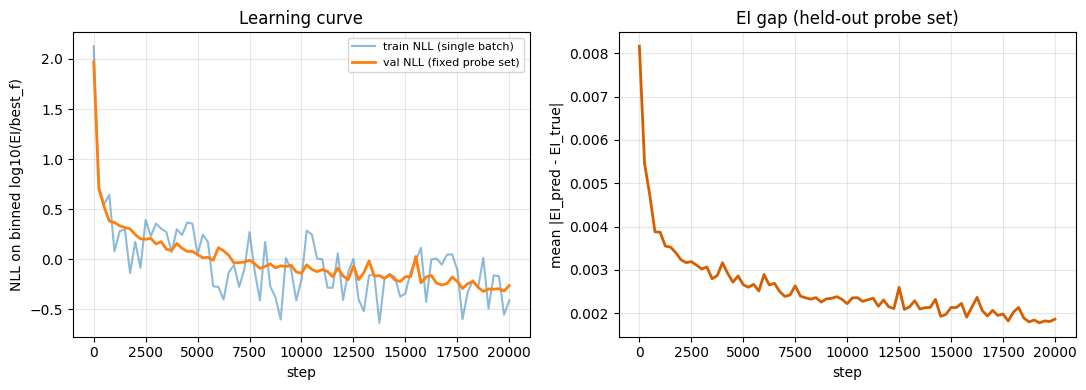

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["step"], history["train_loss"], alpha=0.5, label="train NLL (single batch)")
axes[0].plot(history["step"], history["val_loss"], linewidth=2, label="val NLL (fixed probe set)")
axes[0].set_xlabel("step")
axes[0].set_ylabel("NLL on binned log10(EI/best_f)")
axes[0].set_title("Learning curve")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(history["step"], history["val_ei_gap"], color="#D55E00", linewidth=2)
axes[1].set_xlabel("step")
axes[1].set_ylabel("mean |EI_pred - EI_true|")
axes[1].set_title("EI gap (held-out probe set)")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig("_demo_plots/vla_readout_ei_fit_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()



## Ranking diagnostics

Pooled correlation across many instances can look good even when within-instance ranking (the
thing that actually matters for picking a next query) is weak -- this is exactly what the earlier,
buggy version of this experiment showed (pooled Spearman 0.56 vs. per-instance 0.13). Reporting
both here, plus top-1 hit rate (does `argmax(predicted EI)` pick the actual best candidate) and the
log-space error (a scale-appropriate number to interpret the scatter plot's spread against).


In [6]:

per_instance_rho, top1_hit, z_err = [], [], []
all_ei_true, all_ei_pred = [], []

with torch.no_grad():
    for x_query, train_hidden, incumbent_idx, y_incumbent, ei_true, z_true in VAL_BATCHES:
        logits = readout(x_query, train_hidden, incumbent_idx)
        z_pred = bar_dist_score.mean(logits)
        ei_pred = (10.0 ** z_pred) * y_incumbent.unsqueeze(-1)

        z_err.append((z_pred - z_true).cpu().numpy().flatten())
        all_ei_true.append(ei_true.cpu().flatten())
        all_ei_pred.append(ei_pred.cpu().flatten())

        ei_true_np, ei_pred_np = ei_true.cpu().numpy(), ei_pred.cpu().numpy()
        for b in range(ei_true_np.shape[0]):
            true_b, pred_b = ei_true_np[b], ei_pred_np[b]
            if np.unique(true_b).size > 1:
                rho_b, _ = spearmanr(true_b, pred_b)
                per_instance_rho.append(rho_b)
            top1_hit.append(int(true_b.argmax()) == int(pred_b.argmax()))

per_instance_rho = np.array(per_instance_rho)
z_err = np.concatenate(z_err)
ei_true_cat = torch.cat(all_ei_true).numpy()
ei_pred_cat = torch.cat(all_ei_pred).numpy()
pooled_rho, _ = spearmanr(ei_true_cat, ei_pred_cat)

print(f"pooled Spearman:         {pooled_rho:.4f}")
print(f"per-instance Spearman:   mean {per_instance_rho.mean():.3f}  median {np.median(per_instance_rho):.3f}  "
      f"std {per_instance_rho.std():.3f}  (n={len(per_instance_rho)} instances)")
print(f"top-1 hit rate:          {np.mean(top1_hit):.3f}  ({sum(top1_hit)}/{len(top1_hit)} instances; "
      f"random chance = {1 / N_QUERY:.3f})")
print(f"log10(EI/best_f) error:  MAE {np.abs(z_err).mean():.3f}  RMSE {np.sqrt((z_err ** 2).mean()):.3f}  "
      f"(~{10 ** np.abs(z_err).mean():.2f}x typical multiplicative error)")


pooled Spearman:         0.9725
per-instance Spearman:   mean 0.889  median 0.908  std 0.097  (n=320 instances)
top-1 hit rate:          0.600  (192/320 instances; random chance = 0.031)
log10(EI/best_f) error:  MAE 0.159  RMSE 0.224  (~1.44x typical multiplicative error)


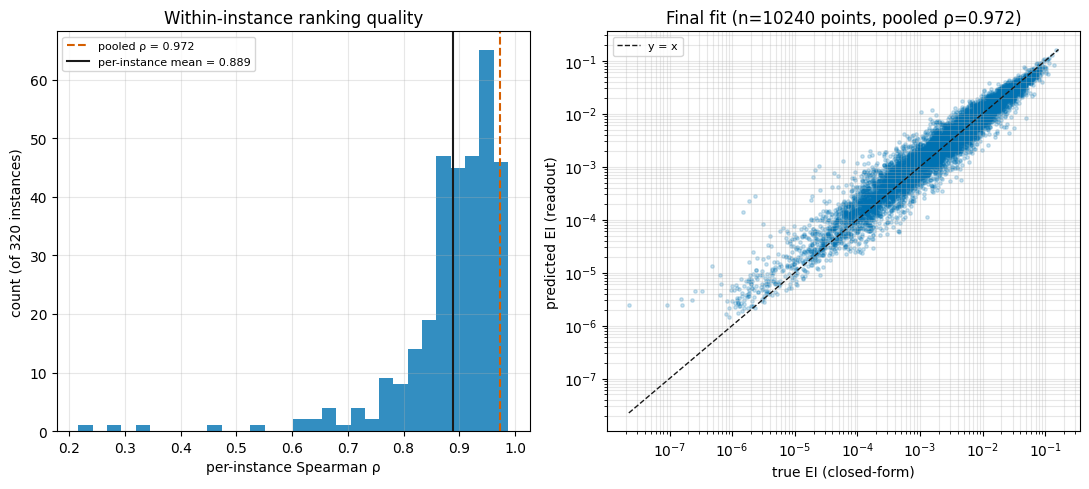

final EI gap (MAE, held-out): 0.0019
final val NLL:                -0.2627


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].hist(per_instance_rho, bins=30, color="#0072B2", alpha=0.8)
axes[0].axvline(pooled_rho, color="#D55E00", linestyle="--", label=f"pooled ρ = {pooled_rho:.3f}")
axes[0].axvline(per_instance_rho.mean(), color="#1a1a1a", linestyle="-", label=f"per-instance mean = {per_instance_rho.mean():.3f}")
axes[0].set_xlabel("per-instance Spearman ρ")
axes[0].set_ylabel(f"count (of {len(per_instance_rho)} instances)")
axes[0].set_title("Within-instance ranking quality")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

mask = (ei_true_cat > EPS) & (ei_pred_cat > EPS)
axes[1].scatter(ei_true_cat[mask], ei_pred_cat[mask], s=6, alpha=0.2, color="#0072B2")
lims = [min(ei_true_cat[mask].min(), ei_pred_cat[mask].min()), max(ei_true_cat[mask].max(), ei_pred_cat[mask].max())]
axes[1].plot(lims, lims, "--", color="#1a1a1a", linewidth=1, label="y = x")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("true EI (closed-form)")
axes[1].set_ylabel("predicted EI (readout)")
axes[1].set_title(f"Final fit (n={mask.sum()} points, pooled ρ={pooled_rho:.3f})")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig("_demo_plots/vla_readout_ei_fit_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"final EI gap (MAE, held-out): {history['val_ei_gap'][-1]:.4f}")
print(f"final val NLL:                {history['val_loss'][-1]:.4f}")
